In [1]:
import numpy as np
import scipy as sp
import scipy.signal as sig
import torch
import networkx as nx
import matplotlib.pyplot as plt

from t_regs.utils.variable_grouping import init_graph_grouping
from t_regs.utils.variable_grouping.graph_total_variation import init_gtv_regularization
from t_regs.proximal_ops.prox_logn import prox_logn_admm
from t_regs.proximal_ops.prox_gtv import prox_gtv_admm

plt.style.use('seaborn-v0_8-paper')
# Set the default font family to serif
plt.rcParams['font.family'] = 'serif' 
# Specify a list of font names to try for the serif family
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Palatino'] 

/mnt/ffs24/home/indibimu/repos/t-regs/src/t_regs/utils/variable_grouping/graph_grouping.py:56: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  G_ind = torch.sparse_csr_tensor(A_r.indptr, # pylint: disable=invalid-name


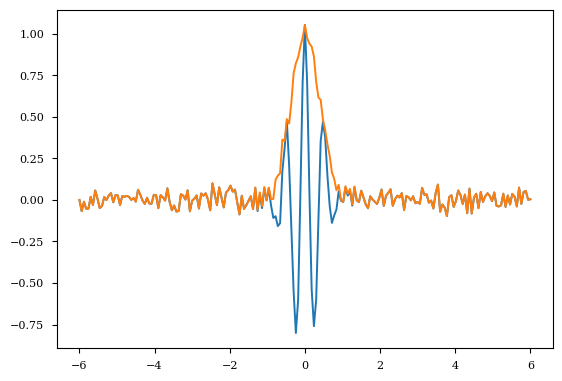

In [2]:
tpoints = 201
t = np.linspace(-6, 6, tpoints)
y, env = sig.gausspulse(t, fc=2, retenv=True)
noise = np.random.randn(tpoints)*0.04
y_n = y+noise
env_n = env + noise
plt.plot(t, y_n, label='gauss pulse')
plt.plot(t, env_n, label='gauss pulse envelope')
# plt.scatter( env < 1e-2)
Gt = nx.grid_graph((tpoints,))
grouping = init_graph_grouping(Gt, grouping='neighbor', device='cuda')

Bt, g_ind, g_weight = init_gtv_regularization(Gt)
BBt = Bt.T @ Bt
Bt = torch.sparse_csr_tensor(Bt.indptr,
                            Bt.indices,
                            Bt.data,
                            device='cuda')
g_ind = torch.sparse_csr_tensor(g_ind.indptr,
                                g_ind.indices,
                                g_ind.data,
                                device='cuda')
BBt = torch.sparse_csr_tensor(BBt.indptr,
                            BBt.indices,
                            BBt.data,
                            device='cuda')
g_weight = torch.tensor(g_weight, device='cuda')

In [ ]:
x = torch.tensor(y, device=grouping.device, dtype=grouping.dtype)
logn_result = prox_logn_admm(x, 0.1, grouping, verbose=False)

In [5]:
lda_res = 6
lda_range = np.linspace(0, 0.3, lda_res)
x_thrs = np.zeros((tpoints, lda_res))
Gt = nx.grid_graph((tpoints,))
grouping = init_graph_grouping(Gt, grouping='edge', device='cuda')
x = torch.tensor(y_n, device=grouping.device, dtype=grouping.dtype)
for i, lda in enumerate(lda_range):
    # if i!=0:
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_thrs[:, i] = logn_result.x.cpu().numpy()
    # else:
    #     x_thrs[:, i] = 



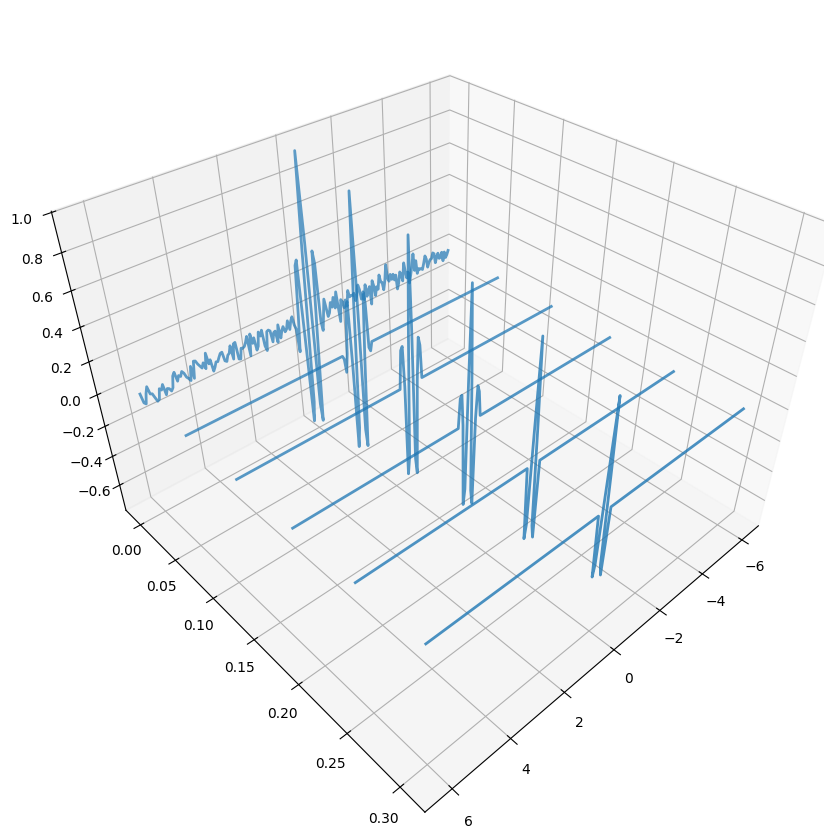

In [6]:
X, Y = np.meshgrid(t,lda_range)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10,10),
                       subplot_kw={'projection':'3d'})
ax.set_proj_type('persp', focal_length=0.25)
ax.view_init(elev=37, azim=47)
# ax.plot_wireframe(X, Y, x_thrs.T, cstride=0)
for i, lda in enumerate(lda_range):
    # if i!=0:
#     logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
#     x_thrs[:, i] = logn_result.x.cpu().numpy()
    ax.plot(t, lda, x_thrs[:, i],
            label=r'$\lambda='+str(lda)+r'$',
            alpha= 0.7+i/(lda_res*8),
            linewidth=2,
            color='C0')

    # ax.legend()

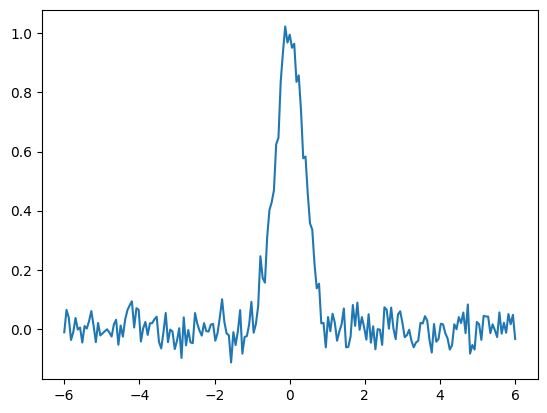

In [127]:
tpoints = 201
t = np.linspace(-6, 6, tpoints)
y, env = sig.gausspulse(t, fc=2, retenv=True)
y_n = env+np.random.randn(201)*0.04
plt.plot(t, y_n, label='gauss pulse')

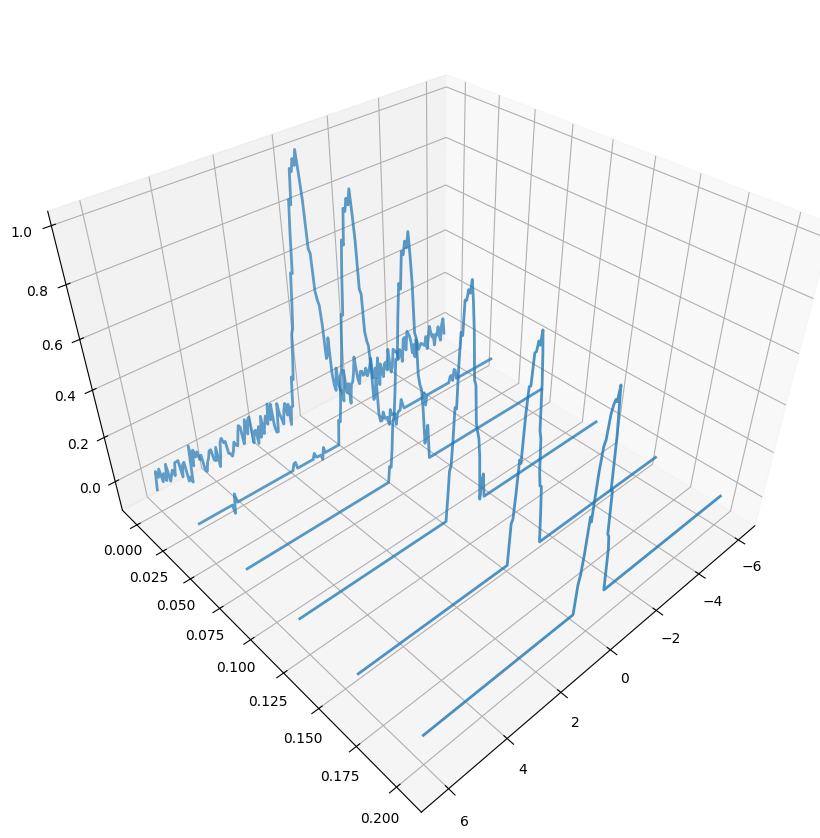

In [ ]:
lda_res = 6
lda_range = np.linspace(0, 0.2, lda_res)
x_thrs = np.zeros((tpoints, lda_res))
Gt = nx.grid_graph((tpoints,))
grouping = init_graph_grouping(Gt, grouping='edge', device='cuda')
x = torch.tensor(y_n, device=grouping.device, dtype=grouping.dtype)
for i, lda in enumerate(lda_range):
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_thrs[:, i] = logn_result.x.cpu().numpy()

X, Y = np.meshgrid(t,lda_range)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10,10),
                       subplot_kw={'projection':'3d'})
ax.set_proj_type('persp', focal_length=0.25)
ax.view_init(elev=37, azim=47)
# ax.plot_wireframe(X, Y, x_thrs.T, cstride=0)
for i, lda in enumerate(lda_range):
    # if i!=0:
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_thrs[:, i] = logn_result.x.cpu().numpy()
    ax.plot(t, lda, x_thrs[:, i],
            label=r'$\lambda='+str(lda)+r'$',
            alpha= 0.7+i/(lda_res*8),
            linewidth=2,
            color='C0')

    # ax.legend()

In [13]:
x.dtype

torch.float32

In [24]:
x = torch.tensor(y, device=grouping.device, dtype=g_ind.dtype)
gtv_result = prox_gtv_admm(x, 0.1, Bt, g_ind, g_weight, BBt, rho=10, max_it=500,
                            verbose=True)

Optimizing for prox GTV...
Iteration    Objective        Lagrangian      Primal Res.     Dual Res.        Aug Lagr.       
---------    -------------    ------------    ------------    -------------    ------------    
  0          +1.204848e+00    1.252743e+00    6.920679e-02    +1.536911e+00    1.598777e+00    
  1          +1.248034e+00    1.249981e+00    8.527695e-03    +1.430397e+00    1.292620e+00    
  2          +1.260671e+00    1.260757e+00    4.659622e-03    +1.288307e+00    1.284055e+00    
  3          +1.272815e+00    1.273025e+00    3.128149e-03    +1.165868e+00    1.288666e+00    
  4          +1.284418e+00    1.284641e+00    2.617421e-03    +1.057949e+00    1.297728e+00    
  5          +1.295271e+00    1.295446e+00    2.091259e-03    +9.620003e-01    1.305902e+00    
  6          +1.305271e+00    1.305376e+00    1.699538e-03    +8.762114e-01    1.313874e+00    
  7          +1.314380e+00    1.314421e+00    1.552265e-03    +7.991993e-01    1.322182e+00    
  8          

In [3]:
Gt = nx.grid_graph((tpoints,))


lda_res = 5
lda_range = np.linspace(0, 0.25, lda_res)
x_gtv = np.zeros((tpoints, lda_res))
x_logn = np.zeros((tpoints, lda_res))
x_l1 = np.zeros((tpoints, lda_res))
x = torch.tensor(y_n, device=g_weight.device, dtype=g_weight.dtype)
grouping = init_graph_grouping(Gt, grouping='neighbor', device='cuda', dtype=g_weight.dtype)
for i, lda in enumerate(lda_range):
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_logn[:, i] = logn_result.x.cpu().numpy()
    
    x_l1[:, i] = torch.nn.functional.softshrink(x, lda).cpu().numpy()
    
    gtv_result = prox_gtv_admm(x, lda,
                            Bt, g_ind, g_weight, BBt, rho=10, max_it=500,
                            verbose=False)
    x_gtv[:, i] = gtv_result.x.cpu().numpy().ravel()


x_env_gtv = np.zeros((tpoints, lda_res))
x_env_logn = np.zeros((tpoints, lda_res))
x_env_l1 = np.zeros((tpoints, lda_res))
x = torch.tensor(env_n, device=g_weight.device, dtype=g_weight.dtype)
grouping = init_graph_grouping(Gt, grouping='edge', device='cuda', dtype=g_weight.dtype)
for i, lda in enumerate(lda_range):
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_env_logn[:, i] = logn_result.x.cpu().numpy()
    
    x_env_l1[:, i] = torch.nn.functional.softshrink(x, lda).cpu().numpy()

    gtv_result = prox_gtv_admm(x, lda,
                            Bt, g_ind, g_weight, BBt, rho=10, max_it=500,
                            verbose=False)
    x_env_gtv[:, i] = gtv_result.x.cpu().numpy().ravel()


In [21]:
fs = 14
fs_p1 = fs + 2
fs_p2 = fs + 4
logn_plot_kw = {
    'linewidth': 3.3,
    'color': 'C0',
}
gtv_plot_kw = {
    'linewidth': 3.0,
    'color': 'C1',
}
l1_plot_kw = {
    'linewidth': 1.5,
    'color': 'C4',
}
offset_t = 12.1
label_kw = {
    'fontsize': fs,
    'weight': 'semibold',
}
legend_kw = {
    'fontsize': fs_p1,
    'loc': 'lower left',
}

text = r"Increasing Regularization $(\lambda) \rightarrow +$"
text_x = -4
text_y = 0.12
text_z = 0
text_zdir = 'y'
text_kw = {
    'fontsize': fs_p1,
    'weight': 'semibold',
}

t_inc = r"Incoherent Anomaly"
t_inc_x = 0-2
t_inc_y = -0.2
t_inc_z = 0.65
t_inc_zdir = 'x'
text_kw = {
    'fontsize': fs_p1,
    'weight': 'semibold',
}
t_coh = r"Coherent Anomaly"
t_coh_x = offset_t+2
t_coh_y = -0.2
t_coh_z = 0.65
t_coh_zdir = 'x'

y_offset = 0.002

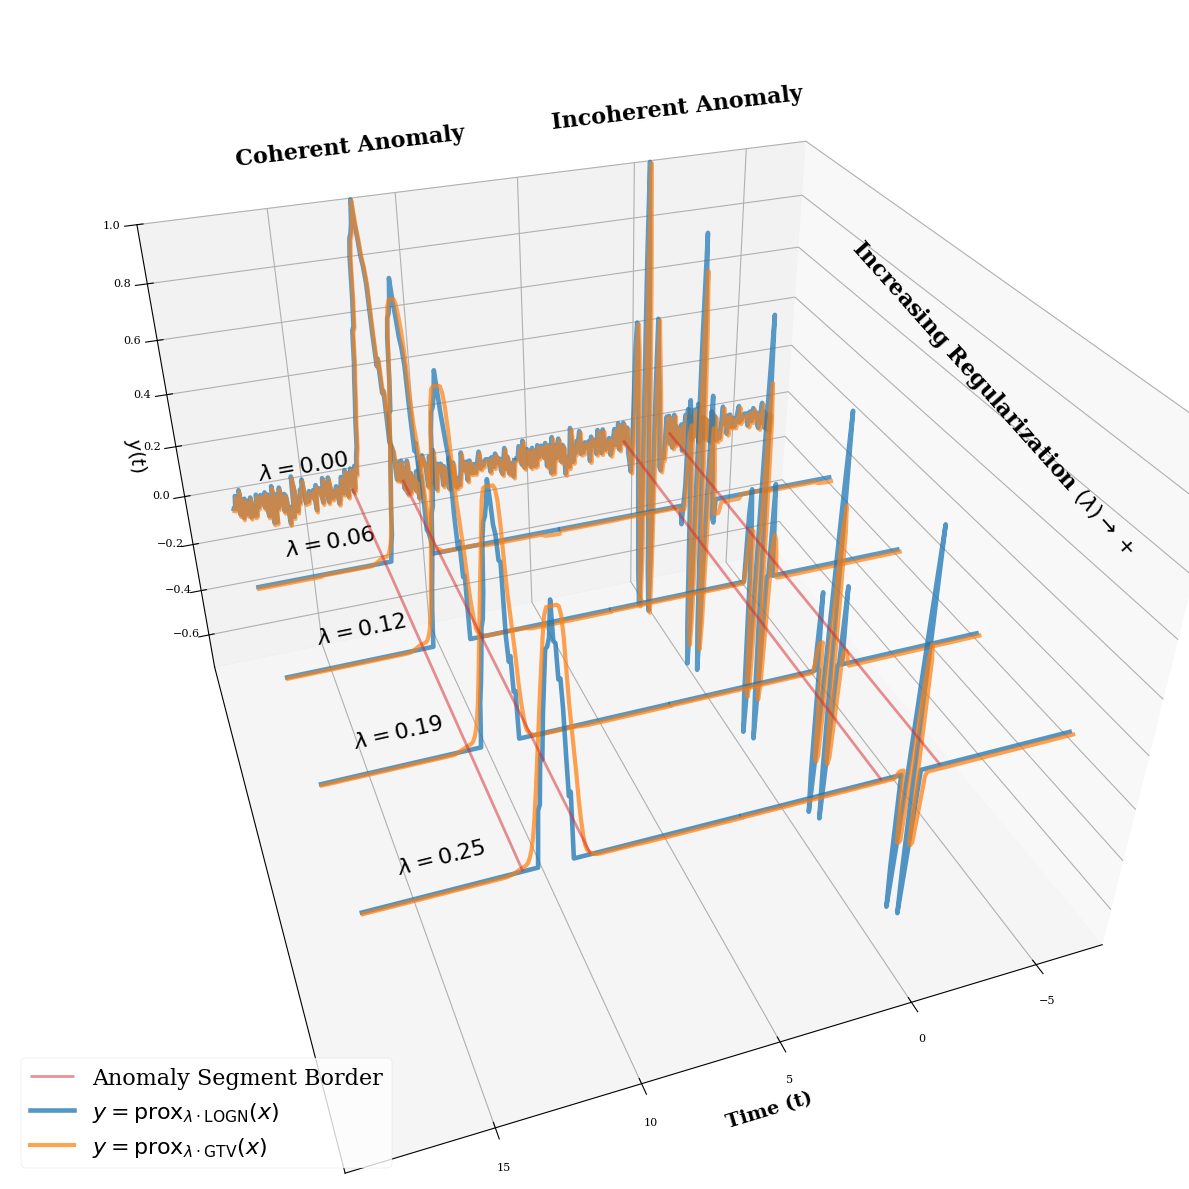

In [25]:

zlim = [-0.65,1.0]
X, Y = np.meshgrid(t,lda_range)
fig, axes = plt.subplots(ncols=1, nrows=1, figsize=(12,14),subplot_kw={'projection':'3d'})
axes = [axes]

for ax in axes:
    ax.set_proj_type('persp', focal_length=0.25)
    ax.view_init(elev=34, azim=70)
    # ax.plot_wireframe(X, Y, x_thrs.T, cstride=0)
    ax.plot_wireframe(t[env>0.01][0], lda_range, np.zeros((1,lda_res)), color='C3', alpha=0.5, linewidth=2)
    ax.plot_wireframe(t[env>0.01][-1], lda_range, np.zeros((1,lda_res)), color='C3', alpha=0.5, linewidth=2)
    ax.plot_wireframe(t[env>0.01][0]+offset_t, lda_range, np.zeros((1,lda_res)), color='C3', alpha=0.5, linewidth=2)
    ax.plot_wireframe(t[env>0.01][-1]+offset_t, lda_range, np.zeros((1,lda_res)), color='C3', alpha=0.5, linewidth=2,
                      label='Anomaly Segment Border')
    # ax.fill_between(t[env>0.01], -0.003, zlim[1],
    #                 t[env>0.01], -0.003, zlim[0], facecolors='red', alpha=.15)

    # ax.fill_between(t[env>0.01]+offset_t, -0.003, zlim[1],
    #                 t[env>0.01]+offset_t, -0.003, zlim[0], facecolors='red', alpha=.15)

for i, lda in enumerate(lda_range):
    axes[0].plot(t, lda, x_logn[:, i],
        alpha= 0.7+i/(lda_res*12),
        **logn_plot_kw
        )
    axes[0].plot(t, lda+y_offset, x_gtv[:, i],
        alpha= 0.65+i/(lda_res*12),
        **gtv_plot_kw,
        )
    # axes[0].plot(t, lda+y_offset*3, x_l1[:, i],
    #     alpha= 0.50+i/(lda_res*12),
    #     **l1_plot_kw,
    #     )
    axes[0].plot(t+offset_t, lda, x_env_logn[:, i],
        alpha= 0.7+i/(lda_res*12),
        **logn_plot_kw,
        label=r'$y = \mathrm{prox}_{\lambda\cdot \mathrm{LOGN}}(x)$' if i==lda_res-1 else None)
    axes[0].plot(t+offset_t, lda+y_offset, x_env_gtv[:, i],
        alpha= 0.65+i/(lda_res*12),
        **gtv_plot_kw,
        label=r'$y = \mathrm{prox}_{\lambda\cdot \mathrm{GTV}}(x)$' if i==lda_res-1 else None)
    # axes[0].plot(t+offset_t, lda+y_offset*3, x_env_l1[:, i],
    #     alpha= 0.50+i/(lda_res*12),
    #     **l1_plot_kw,
    #     label=r'$\mathbf{y} = \mathrm{prox}_{\lambda\cdot \ell_1}(\mathbf{x})$' if i==lda_res-1 else None)

zdirs = ['x' for _ in lda_range]
xs = [17 for _ in lda_range]
ys = [lda for lda in lda_range]
zs = [0.1 for _ in lda_range]

for zdir, x, y, z in zip(zdirs, xs, ys, zs):
    label = r'$\lambda=' + f'{y:.2f}$'
    axes[0].text(x, y, z, label, zdir, **text_kw)

axes[0].text(t_inc_x, t_inc_y, t_inc_z, t_inc, t_inc_zdir, **text_kw)
axes[0].text(t_coh_x, t_coh_y, t_coh_z, t_coh, t_coh_zdir, **text_kw)

for ax in axes:
    ax.text(text_x, text_y, text_z, text, text_zdir, **text_kw)
    ax.legend( **legend_kw)
    ax.set_xlabel("Time (t)", **label_kw)
    # ax.set_ylabel(r"Regularization $\lambda$", **label_kw)
    ax.set_yticks([])
    ax.set_zlabel(r"$y(t)$", **label_kw)
    ax.set_zlim([-0.75,1])
    # ax.grid(False)
fig.tight_layout()

AttributeError: 'int' object has no attribute 'device'

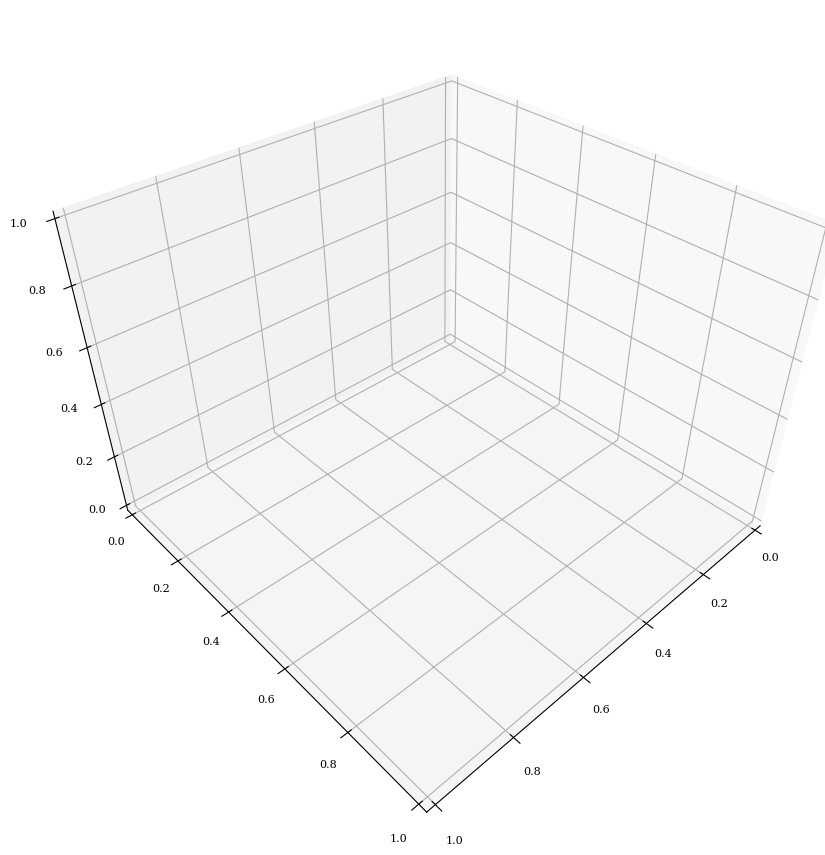

In [38]:
X, Y = np.meshgrid(t,lda_range)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10,10),
                       subplot_kw={'projection':'3d'})
ax.set_proj_type('persp', focal_length=0.25)
ax.view_init(elev=37, azim=47)
# ax.plot_wireframe(X, Y, x_thrs.T, cstride=0)
for i, lda in enumerate(lda_range):
    # if i!=0:
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_thrs[:, i] = logn_result.x.cpu().numpy()
    ax.plot(t, lda, x_thrs[:, i],
            label=r'$\lambda='+str(lda)+r'$',
            alpha= 0.7+i/(lda_res*8),
            linewidth=2,
            color='C0')

    # ax.legend()

In [ ]:
lda_res = 6
lda_range = np.linspace(0, 0.2, lda_res)
x_thrs = np.zeros((tpoints, lda_res))
Gt = nx.grid_graph((tpoints,))
grouping = init_graph_grouping(Gt, grouping='edge', device='cuda')
x = torch.tensor(y_n, device=grouping.device, dtype=grouping.dtype)

for i, lda in enumerate(lda_range):
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_thrs[:, i] = logn_result.x.cpu().numpy()

X, Y = np.meshgrid(t,lda_range)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10,10),
                       subplot_kw={'projection':'3d'})
ax.set_proj_type('persp', focal_length=0.25)
ax.view_init(elev=37, azim=47)
# ax.plot_wireframe(X, Y, x_thrs.T, cstride=0)
for i, lda in enumerate(lda_range):
    # if i!=0:
    logn_result = prox_logn_admm(x, lda, grouping, verbose=False)
    x_thrs[:, i] = logn_result.x.cpu().numpy()
    ax.plot(t, lda, x_thrs[:, i],
            label=r'$\lambda='+str(lda)+r'$',
            alpha= 0.7+i/(lda_res*8),
            linewidth=2,
            color='C0')

    # ax.legend()